# Alternative unsupervised methodologies

In this frameworkm we explore alternative clustering methodologies for creating profile groups.

## Imports

In [82]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, QuantileTransformer

import numpy as np

from collections import Counter

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import hdbscan
import kneed

## Load data

In [2]:
readings_task_usage_df = pd.read_csv("data/sample_jobs_summary_10perc.csv", header=[0,1], index_col=[0])

In [3]:
readings_task_usage_df

CPU rate           canonical memory usage            \
                mean       std                   mean       std   
job ID                                                            
3418356     0.036646  0.018963               0.080511  0.000850   
3418405     0.033089  0.023353               0.082067  0.001213   
6724949     0.000554  0.000375               0.078749  0.001790   
28185708    0.000654  0.000272               0.005977  0.001609   
124371644   0.000083  0.000133               0.020451  0.000204   
...              ...       ...                    ...       ...   
6486612269  0.001944  0.002809               0.000313  0.000542   
6486612710  0.021116  0.021414               0.003314  0.003417   
6486630408  0.000629  0.001184               0.000204  0.000413   
6486631154  0.000535  0.000899               0.000249  0.000498   
6486631394  0.002621  0.001527               0.000614  0.000533   

           local disk space usage           active tasks              \
                             mean       std         mean         std   
job ID                                                                 
3418356                  0.000282  0.000072     4.998204    0.052449   
3418405                  0.000218  0.000042     3.996887    0.061824   
6724949                  0.000192  0.000014     1.998922    0.032811   
28185708                 0.000000  0.000000     9.776516    3.269454   
124371644                0.000047  0.000002     1.999162    0.028940   
...                           ...       ...          ...         ...   
6486612269               0.000000  0.000000     1.000000    0.000000   
6486612710               0.000001  0.000001    22.382022  105.542592   
6486630408               0.000000  0.000000     1.285714    0.487950   
6486631154               0.000000  0.000000     1.000000    0.000000   
6486631394               0.000000  0.000000     1.000000    0.000000   

              job runtime  
                     vals  
job ID                     
3418356     2505600000000  
3418405     2505600000000  
6724949     2505600000000  
28185708    2505600000000  
124371644   2505600000000  
...                   ...  
6486612269       24000000  
6486612710      222000000  
6486630408       85000000  
6486631154       63000000  
6486631394       63000000  

[65421 rows x 9 columns]

In [4]:
readings_task_usage_df.dropna(inplace=True)

### Perform some preprocessing

In [83]:
# scaler = RobustScaler()
# scaled = scaler.fit_transform(readings_task_usage_df)

In [84]:
qt = QuantileTransformer(output_distribution='uniform', n_quantiles=1000, random_state=42)
scaled = qt.fit_transform(readings_task_usage_df)

## PyTorch autoencoders

In [85]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split

In [86]:
# Convert to PyTorch tensor
X = torch.tensor(scaled, dtype=torch.float32)

In [87]:
#--------------------------------#
# 2. Define Autoencoder Model
#--------------------------------#

# In this case we have 9 input features 
input_dim = X.shape[1]  # e.g., 9
latent_dim = 3  # target dimension for clustering

class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, latent_dim)
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon

# Instantiate model
model = Autoencoder(input_dim, latent_dim)


In [88]:
#--------------------------------#
# Create Datasets and Dataloaders
#--------------------------------#
dataset = TensorDataset(X)

# Split the dataset into training and validation sets
val_ratio = 0.1
val_size = int(len(dataset) * val_ratio)
train_size = len(dataset) - val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

#--------------------------------#
# Early Stopping Parameters
#--------------------------------#
patience = 20
best_val_loss = float('inf')
epochs_no_improve = 0
max_epochs = 500  # you can increase if you want

model.train()
for epoch in range(max_epochs):
    # Training loop
    model.train()
    train_loss = 0.0
    for batch_data, in train_loader:
        optimizer.zero_grad()
        reconstructed = model(batch_data)
        loss = criterion(reconstructed, batch_data)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch_data.size(0)
    train_loss /= len(train_loader.dataset)

    # Validation loop
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_data, in val_loader:
            reconstructed = model(batch_data)
            loss = criterion(reconstructed, batch_data)
            val_loss += loss.item() * batch_data.size(0)
    val_loss /= len(val_loader.dataset)
    
    print(f"Epoch {epoch+1}/{max_epochs}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

    # Check for improvement
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        # Optionally save the best model
        # torch.save(model.state_dict(), 'best_autoencoder.pt')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping triggered. No improvement after", patience, "epochs.")
            break

print("Training completed. Best validation loss:", best_val_loss)


Epoch 1/500, Train Loss: 0.043290, Val Loss: 0.009139
Epoch 2/500, Train Loss: 0.008303, Val Loss: 0.008062
Epoch 3/500, Train Loss: 0.007653, Val Loss: 0.007625
Epoch 4/500, Train Loss: 0.007210, Val Loss: 0.007193
Epoch 5/500, Train Loss: 0.006729, Val Loss: 0.006691
Epoch 6/500, Train Loss: 0.006324, Val Loss: 0.006413
Epoch 7/500, Train Loss: 0.005927, Val Loss: 0.005860
Epoch 8/500, Train Loss: 0.005568, Val Loss: 0.005649
Epoch 9/500, Train Loss: 0.005308, Val Loss: 0.005280
Epoch 10/500, Train Loss: 0.004950, Val Loss: 0.004863
Epoch 11/500, Train Loss: 0.004702, Val Loss: 0.004736
Epoch 12/500, Train Loss: 0.004540, Val Loss: 0.004575
Epoch 13/500, Train Loss: 0.004415, Val Loss: 0.004418
Epoch 14/500, Train Loss: 0.004333, Val Loss: 0.004421
Epoch 15/500, Train Loss: 0.004264, Val Loss: 0.004356
Epoch 16/500, Train Loss: 0.004214, Val Loss: 0.004230
Epoch 17/500, Train Loss: 0.004167, Val Loss: 0.004186
Epoch 18/500, Train Loss: 0.004129, Val Loss: 0.004267
Epoch 19/500, Train

In [90]:
#--------------------------------#
# 4. Extract Embeddings for Clustering
#--------------------------------#

model.eval()
with torch.no_grad():
    embeddings = model.encoder(X)  # This is now [n_samples, latent_dim]

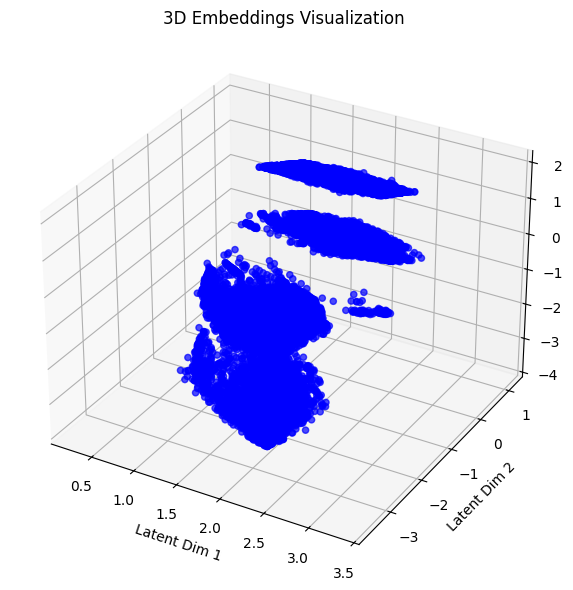

In [91]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # This is needed for 3D plotting

# Suppose 'embeddings' is a PyTorch tensor or NumPy array of shape [N, 3]
# If embeddings is a PyTorch tensor, first convert it to NumPy:
emb_array = embeddings.detach().cpu().numpy() if isinstance(embeddings, torch.Tensor) else embeddings

# Extract coordinates
x = emb_array[:, 0]
y = emb_array[:, 1]
z = emb_array[:, 2]

# Optional: If you have cluster labels or classes, use them to color the points
# For instance, assume 'cluster_labels' is an array of length N with integer labels.
# Otherwise, you can skip this and choose a single color.
cluster_labels = None  # Replace with your actual labels if you have them

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# If you have cluster labels, use them to determine the color map
if cluster_labels is not None:
    scatter = ax.scatter(x, y, z, c=cluster_labels, cmap='viridis', s=20, alpha=0.7)
    cbar = fig.colorbar(scatter, ax=ax)
    cbar.set_label('Cluster/Label')
else:
    ax.scatter(x, y, z, color='blue', s=20, alpha=0.7)

ax.set_xlabel('Latent Dim 1')
ax.set_ylabel('Latent Dim 2')
ax.set_zlabel('Latent Dim 3')
ax.set_title('3D Embeddings Visualization')

plt.tight_layout()
plt.show()


## DBSCAN

### K-Dist graph

First of all, we compute the k-dist graph, i.e., a plot that helps investigating one of the best $\epsilon$ value for DBSCAN. In fact, DBSCAN is based on two essential parameters:
1. $\epsilon$: the radius of the hypersphere where DBSCAN looks for neighbors
2. $MinPoints$: the minimum number of points necessary to declare an area (the sphere with radius $\epsilon$) as dense.

In [96]:
# https://stackoverflow.com/questions/43160240/how-to-plot-a-k-distance-graph-in-python

minPts = 100
k = minPts - 1

# 1. Compute the k-th nearest neighbor distances for each point
nbrs = NearestNeighbors(n_neighbors=k).fit(embeddings.numpy())
distances, indices = nbrs.kneighbors(embeddings.numpy())

In [97]:
# distances[:, k-1] gives the distance to the k-th nearest neighbor for each point
k_distances = distances[:, k-1]
k_distances = np.sort(k_distances)  # sort the distances


In [112]:
from kneed import KneeLocator

kneedle = KneeLocator(range(len(k_distances)), k_distances, S=10000.0, curve='convex', direction='increasing')
knee_point = kneedle.knee
epsilon = k_distances[knee_point]

print("Estimated epsilon:", epsilon)

Estimated epsilon: 0.07861263897683761


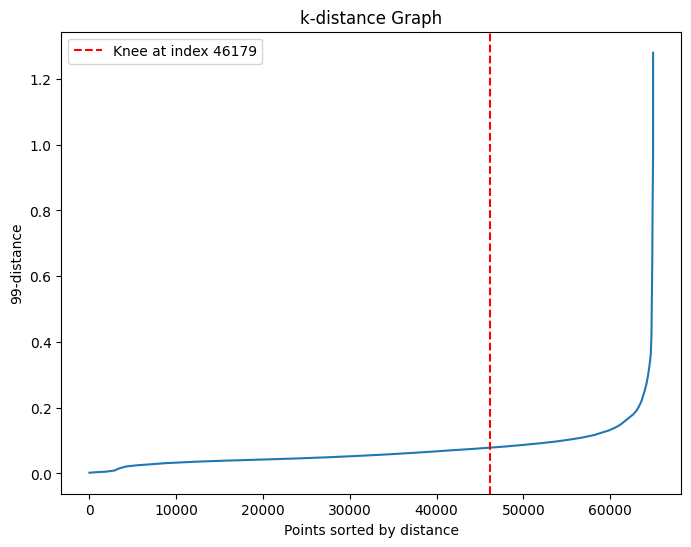

In [113]:
# 3. Plot the k-distance graph and the identified elbow
plt.figure(figsize=(8, 6))
plt.plot(k_distances)
if knee_point is not None:
    plt.axvline(x=knee_point, color='r', linestyle='--', label=f'Knee at index {knee_point}')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{k}-distance')
plt.title('k-distance Graph')
plt.legend()
plt.show()

In [30]:
len(X)

64933

In [16]:
#!pip install kneed

In [31]:
#k_sample[int(len(k_sample)*0.9)]

In [122]:
dbscan_clustering = DBSCAN(eps=epsilon, min_samples=100).fit(embeddings.numpy())

In [123]:
Counter(dbscan_clustering.labels_)

Counter({np.int64(1): 35724,
         np.int64(-1): 10293,
         np.int64(0): 6339,
         np.int64(5): 5485,
         np.int64(2): 2014,
         np.int64(6): 1774,
         np.int64(3): 1106,
         np.int64(7): 664,
         np.int64(4): 339,
         np.int64(12): 297,
         np.int64(9): 279,
         np.int64(10): 246,
         np.int64(11): 220,
         np.int64(8): 153})

## HDBSCAN

In [124]:
hdbscan_clusterer = hdbscan.HDBSCAN(min_cluster_size=100, gen_min_span_tree=True)
hdbscan_clusterer.fit(embeddings.numpy())

/opt/anaconda3/envs/ray_env_py310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/ray_env_py310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


HDBSCAN(gen_min_span_tree=True, min_cluster_size=100)

<Axes: ylabel='$\\lambda$ value'>

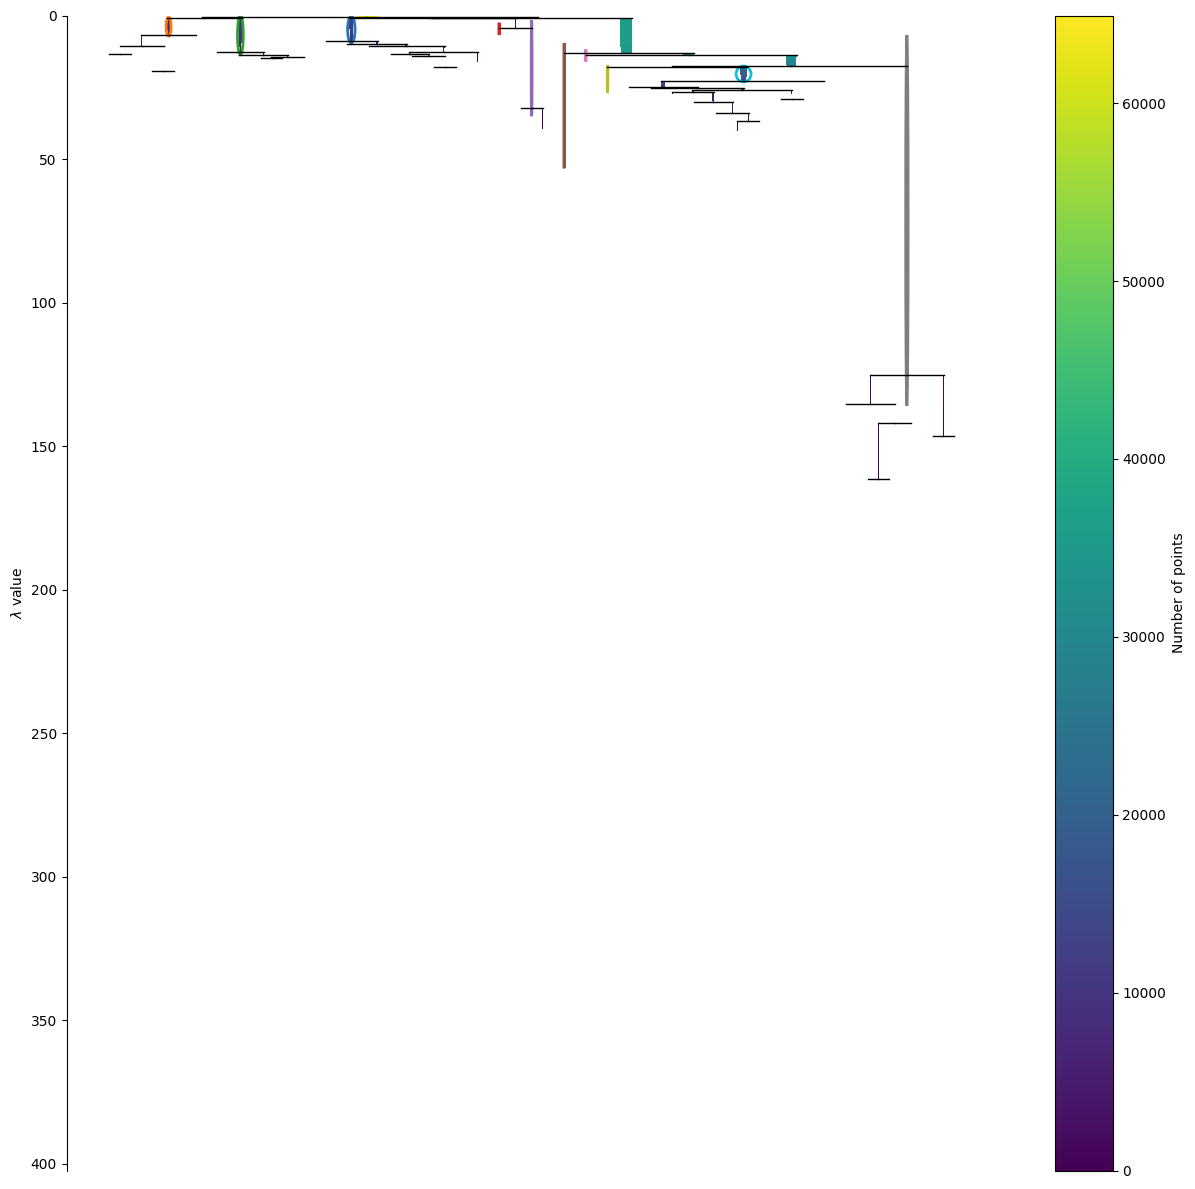

In [125]:
plt.figure(figsize=(15,15))
hdbscan_clusterer.condensed_tree_.plot(select_clusters=True, selection_palette=sns.color_palette())

## Metadata analysis in place

In [119]:
# Load existing data
static_metrics_path = "data/static_metrics_and_kmeans.csv"
static_metrics = pd.read_csv(static_metrics_path)

In [121]:
static_metrics

,job ID,priority,different machines restriction,disk space request - Q1,disk space request - Q2,disk space request - Q3,disk space request - Q4,disk space request - Quartiles,memory request - Q1,memory request - Q2,...,CPU request - Quartiles,priority labels,user,logical job name,scheduling class,K-Means = 2,K-Means = 4,K-Means = 6,K-Means = 8,K-Means = 10
0,3418356,9,0,0,0,0,1,Q4,0,0,...,Q4,Production [9],70s3v5qRyCO/1PCdI6fVXnrW8FU/w+5CKRSa72xgcIo=,fGRnr2XEPDr3kQsPccU/k1LELeeQonkj6hDpTP7ALkg=,3,0,1,1,1,1
1,3418405,9,0,0,0,0,1,Q4,0,0,...,Q4,Production [9],70s3v5qRyCO/1PCdI6fVXnrW8FU/w+5CKRSa72xgcIo=,q6nwarTUw/Xct0ONQEdblvVhW8uWTquTp8C5la5YfRE=,3,0,1,1,1,1
2,6724949,9,0,0,0,0,1,Q4,0,0,...,Q4,Production [9],70s3v5qRyCO/1PCdI6fVXnrW8FU/w+5CKRSa72xgcIo=,4my5Elvc5RumesxoVeuFovkoS28KYA9C3pIBi2bY5Io=,3,0,1,1,1,1
3,28185708,1,0,1,0,0,0,Q1,0,1,...,Q3,"Free [0,1]",WVtO5qw3sNnP4MeiRUnqr07CekrYMU12Mc7GbsgnjhQ=,JGBCBdeRFciFaU6LrbO9Y5w1lBoZ1MyX5Pnx4m05HK8=,2,0,1,1,1,1
4,124371644,9,0,0,0,0,1,Q4,0,0,...,Q3,Production [9],70s3v5qRyCO/1PCdI6fVXnrW8FU/w+5CKRSa72xgcIo=,HcYZ4RNZRxmh/W+WuzNBOVk4sOCdDshVEB/McWxfyyk=,3,0,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64928,6486612269,1,0,0,1,0,0,Q2,0,0,...,Q3,"Free [0,1]",E+9U+J1Dicd5PJklbq2e5THQ29X6D8jmqQ0Zu53Kc+o=,QZm5VyyEiL9TpVhasvtcMxPxENJqlNX4Fn2LdEe+Ff0=,1,1,0,0,0,0
64929,6486612710,4,0,0,0,0,1,Q4,0,0,...,Q2,"Other [2,8]",HxdST/yDI1TlIkr0Povf9KaXGGG8x4iVXX6o/iSIghM=,YI5372ouHbbTv6b594D2bDWC283uv6QcuE41Mst3BFk=,0,1,3,5,5,4
64930,6486630408,4,0,0,1,0,0,Q2,1,0,...,Q3,"Other [2,8]",fJeARInTaIjFrdXGqxap6x2T3TpJB84y9zvFsoGGhjk=,ZoHIMIMjYenKtCPq0iy70XUxyF0JDf1HuW6yUzS4dBM=,0,1,0,0,0,0
64931,6486631154,8,0,0,1,0,0,Q2,0,1,...,Q2,"Other [2,8]",fJeARInTaIjFrdXGqxap6x2T3TpJB84y9zvFsoGGhjk=,cLRsAgA+ajg6giausco6dsV5PxWsqEJZDLdHWhd6v0E=,2,1,0,0,0,0


In [126]:
static_metrics['DBSCAN'] = dbscan_clustering.labels_
static_metrics['HDBSCAN'] = hdbscan_clusterer.labels_

static_metrics

,job ID,priority,different machines restriction,disk space request - Q1,disk space request - Q2,disk space request - Q3,disk space request - Q4,disk space request - Quartiles,memory request - Q1,memory request - Q2,...,user,logical job name,scheduling class,K-Means = 2,K-Means = 4,K-Means = 6,K-Means = 8,K-Means = 10,DBSCAN,HDBSCAN
0,3418356,9,0,0,0,0,1,Q4,0,0,...,70s3v5qRyCO/1PCdI6fVXnrW8FU/w+5CKRSa72xgcIo=,fGRnr2XEPDr3kQsPccU/k1LELeeQonkj6hDpTP7ALkg=,3,0,1,1,1,1,-1,1
1,3418405,9,0,0,0,0,1,Q4,0,0,...,70s3v5qRyCO/1PCdI6fVXnrW8FU/w+5CKRSa72xgcIo=,q6nwarTUw/Xct0ONQEdblvVhW8uWTquTp8C5la5YfRE=,3,0,1,1,1,1,-1,1
2,6724949,9,0,0,0,0,1,Q4,0,0,...,70s3v5qRyCO/1PCdI6fVXnrW8FU/w+5CKRSa72xgcIo=,4my5Elvc5RumesxoVeuFovkoS28KYA9C3pIBi2bY5Io=,3,0,1,1,1,1,-1,1
3,28185708,1,0,1,0,0,0,Q1,0,1,...,WVtO5qw3sNnP4MeiRUnqr07CekrYMU12Mc7GbsgnjhQ=,JGBCBdeRFciFaU6LrbO9Y5w1lBoZ1MyX5Pnx4m05HK8=,2,0,1,1,1,1,-1,2
4,124371644,9,0,0,0,0,1,Q4,0,0,...,70s3v5qRyCO/1PCdI6fVXnrW8FU/w+5CKRSa72xgcIo=,HcYZ4RNZRxmh/W+WuzNBOVk4sOCdDshVEB/McWxfyyk=,3,0,1,1,1,1,-1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64928,6486612269,1,0,0,1,0,0,Q2,0,0,...,E+9U+J1Dicd5PJklbq2e5THQ29X6D8jmqQ0Zu53Kc+o=,QZm5VyyEiL9TpVhasvtcMxPxENJqlNX4Fn2LdEe+Ff0=,1,1,0,0,0,0,1,-1
64929,6486612710,4,0,0,0,0,1,Q4,0,0,...,HxdST/yDI1TlIkr0Povf9KaXGGG8x4iVXX6o/iSIghM=,YI5372ouHbbTv6b594D2bDWC283uv6QcuE41Mst3BFk=,0,1,3,5,5,4,-1,1
64930,6486630408,4,0,0,1,0,0,Q2,1,0,...,fJeARInTaIjFrdXGqxap6x2T3TpJB84y9zvFsoGGhjk=,ZoHIMIMjYenKtCPq0iy70XUxyF0JDf1HuW6yUzS4dBM=,0,1,0,0,0,0,5,2
64931,6486631154,8,0,0,1,0,0,Q2,0,1,...,fJeARInTaIjFrdXGqxap6x2T3TpJB84y9zvFsoGGhjk=,cLRsAgA+ajg6giausco6dsV5PxWsqEJZDLdHWhd6v0E=,2,1,0,0,0,0,1,9


In [131]:
static_metrics.to_csv('data/static_metrics-kMeans-DBSCAN-HDBSCAN.csv')

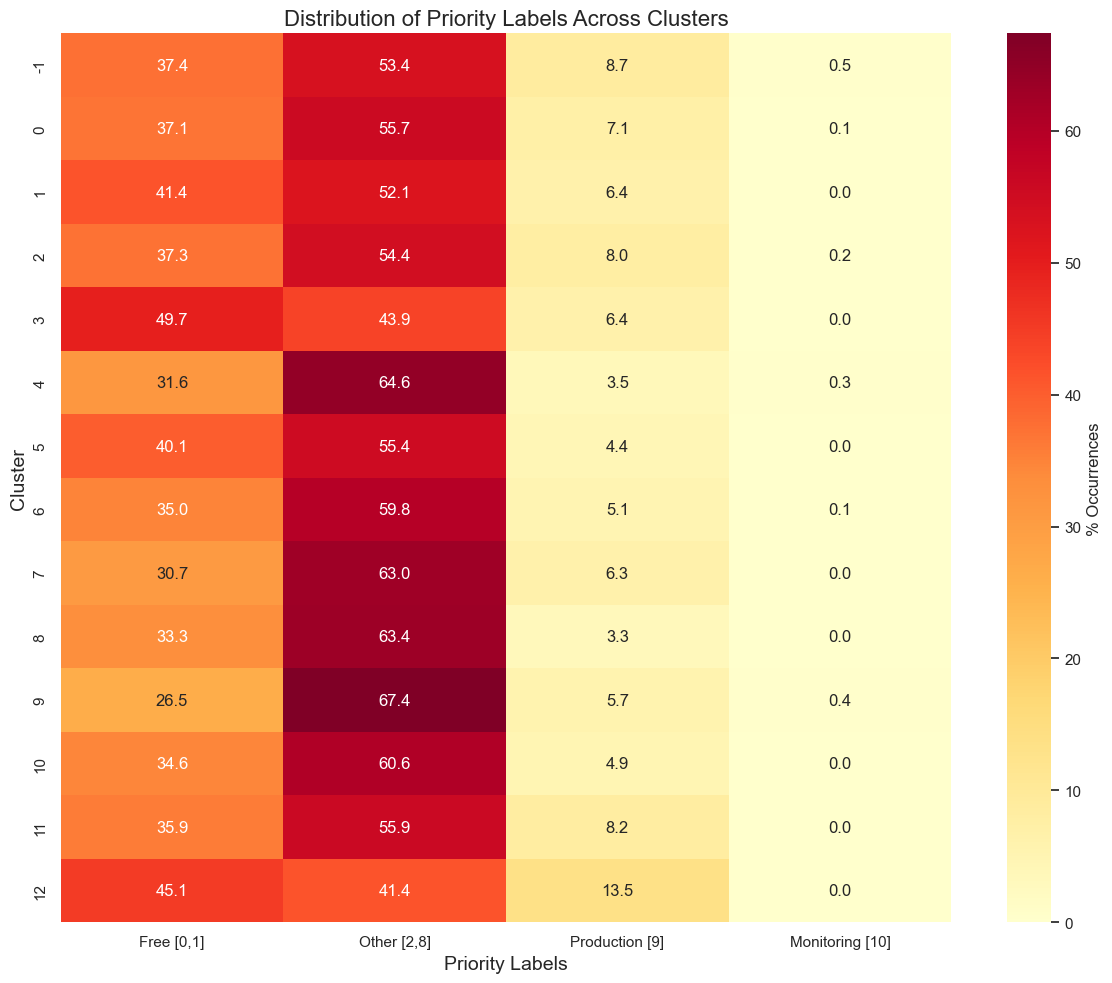

In [129]:
label = "priority labels"
priority_labels = ["Free [0,1]", "Other [2,8]", "Production [9]", "Monitoring [10]"] #, "Infrastructure [11]"]

# Create a contingency table: rows = clusters, columns = priority label categories
ct = pd.crosstab(static_metrics['DBSCAN'], static_metrics[label])

# Ensure that all priority_labels are present, even if they don't appear in some clusters
for plab in priority_labels:
    if plab not in ct.columns:
        ct[plab] = 0

# Reorder columns according to the defined priority_labels
ct = ct[priority_labels]

# Convert counts to percentages by dividing each row by its sum
ct_percentage = ct.div(ct.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 10))
sns.set(style="whitegrid")

# Create the heatmap with a chosen color palette (e.g., "YlOrRd")
sns.heatmap(ct_percentage, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': '% Occurrences'})

plt.title('Distribution of Priority Labels Across Clusters', fontsize=16)
plt.xlabel('Priority Labels', fontsize=14)
plt.ylabel('Cluster', fontsize=14)

plt.tight_layout()
plt.show()

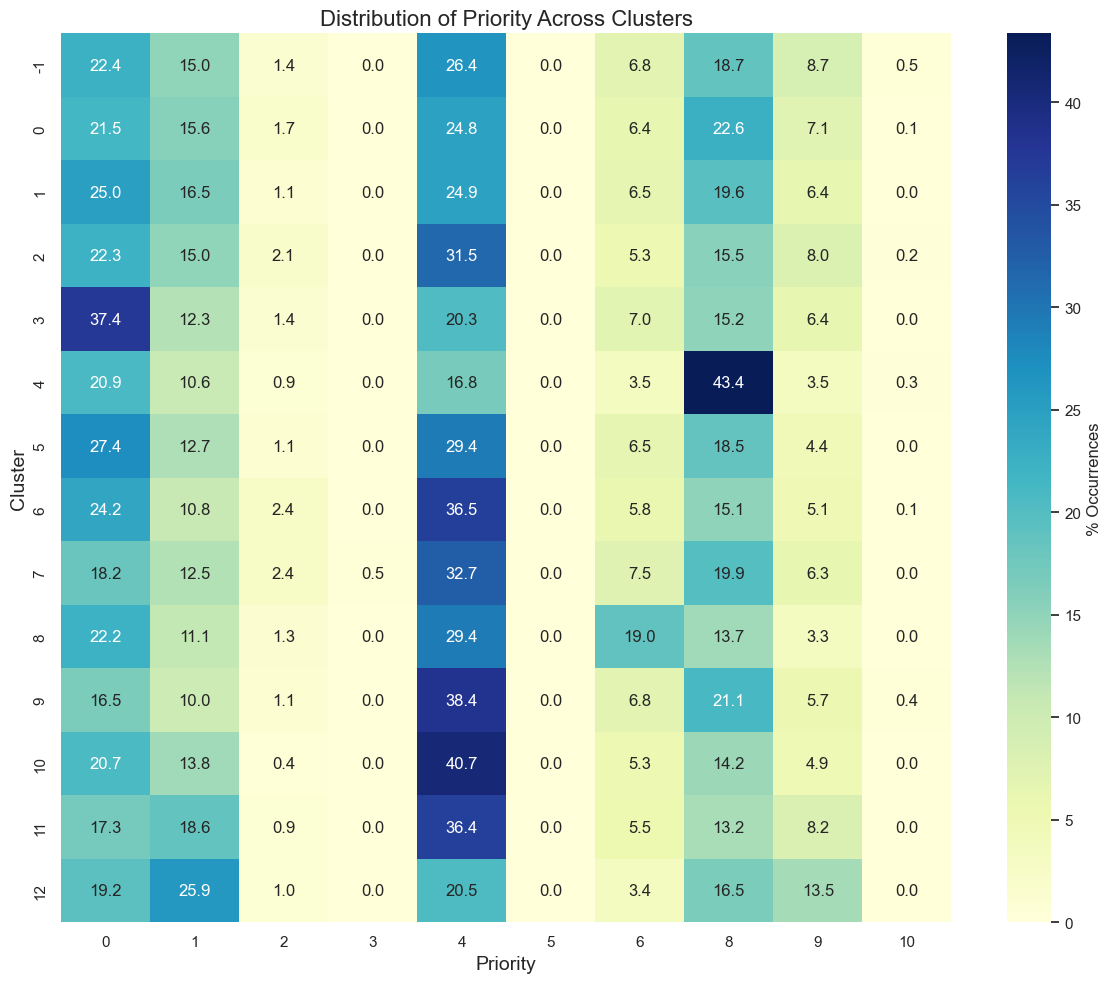

In [130]:
label = "priority"

# Create a contingency table: rows = clusters, columns = priority classes (0 through 11), values = counts
ct = pd.crosstab(static_metrics['DBSCAN'], static_metrics[label])

# Convert counts to percentages by dividing each row by its row sum
ct_percentage = ct.div(ct.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 10))
sns.set(style="whitegrid")

# Plot the heatmap with a different colormap
sns.heatmap(ct_percentage, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': '% Occurrences'})

plt.title('Distribution of Priority Across Clusters', fontsize=16)
plt.xlabel('Priority', fontsize=14)
plt.ylabel('Cluster', fontsize=14)

plt.tight_layout()
plt.show()

## Watermark

In [118]:
%load_ext watermark
%watermark
%watermark --iversions

Last updated: 2024-12-11T09:16:53.897690+01:00

Python implementation: CPython
Python version       : 3.10.15
IPython version      : 8.30.0

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 4.18.0-193.28.1.el8_2.x86_64
Machine     : x86_64
Processor   : x86_64
CPU cores   : 80
Architecture: 64bit

seaborn   : 0.13.2
matplotlib: 3.9.3
pandas    : 2.2.3
sklearn   : 1.6.0
numpy     : 2.2.0
kneed     : 0.8.5
hdbscan   : 0.8.40
torch     : 2.5.1+cu118

